In [1]:
import os
import sys
import time
import glob
import argparse
import traceback
#! pip install ascii
#from ascii import header, footer
from datetime import datetime, timezone
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo

import json
import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

from scipy.fft import rfft, rfftfreq
from scipy.stats import beta

#from PyPDF2 import PdfMerger
#from PyPDF2 import PdfReader, PdfWriter

In [2]:
## define system constants ##
SAMPLE_RATE = 0.016 # us
N_ADCS = 8
N_CHANNELS = 64
N_SIPMS = 48
BIT = 4  # factor from unused ADC bits on LRS: would be nice to have in a resource .yaml
PRE_NOISE = 50 # Will need to be re-defined once we know beam timing
THRESHOLD = 600 # For the FFT, used to define events with signal peaks
SAT = 32767
EXPECTED_RATE = 60 # In Hz, obviously depends on subrun conditions
FPROMPT_THD = 10 # Hz over expected trigger rate considered allowable

ARRIVAL_TICK = 77
CT = ZoneInfo("America/Chicago")
UTC = ZoneInfo("UTC")
    
sipm_channels = ([4,5,6,7,8,9] + \
                 [10,11,12,13,14,15] + \
                 [20,21,22,23,24,25] + \
                 [26,27,28,29,30,31] + \
                 [36,37,38,39,40,41] + \
                 [42,43,44,45,46,47] + \
                 [52,53,54,55,56,57] + \
                 [58,59,60,61,62,63])

In [3]:
#input_file = f'/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin1/two_trig_40us_period_500tick/intensity_scan/hv_60kV_beamC_20uA/mpd_run_data_rctl_961_p2.FLOW.hdf5'
#input_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin1/two_trig_40us_period_500tick/intensity_scan/hv_60kV_beamC_20uA/decays/mpd_run_data_rctl_967_p42.FLOW.hdf5'
#input_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cosmics_hvramp_down_12162025/mpd_run_data_rctl_987_p6.FLOW.hdf5'
#input_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cosmics_bin15/mpd_run_data_rctl_984_p172.FLOW.hdf5'
#input_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cosmics_hvtests_12152025/mpd_run_data_rctl_983_p23.FLOW.hdf5'
#input_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin3/two_trig_32us_period_20251112/mpd_run_data_rctl_657_p2.FLOW.hdf5'

input_file = '/global/cfs/cdirs/dune/users/ajwhite/FLOW_122025/Run1_July10_v12_JuneEvBuilderFlow_files/mpd_run_hvramp_rctl_105_p250.FLOW.hdf5'

In [4]:
## open file ##
file = h5py.File(input_file, 'r')
size_bytes = os.path.getsize(input_file)
size_gb = size_bytes / (1024 ** 3)
print(f"File size: {size_gb:.2f} GB")

MULT = int(size_gb // 3)
if MULT < 1:
    MULT = 1
print(f"Using MULT = {MULT} for data reduction.")

File size: 3.81 GB
Using MULT = 1 for data reduction.


In [5]:
''' V1 
def get_fprompt_estimate(input_file):
    ## open file ##
    file = h5py.File(input_file, 'r')
    size_bytes = os.path.getsize(input_file)
    size_gb = size_bytes / (1024 ** 3)
    print(f"File size: {size_gb:.2f} GB")

    MULT = int(size_gb // 2)
    if MULT < 1:
        MULT = 1
    print(f"Using MULT = {MULT} for data reduction.")

    NUM_EVENTS = len(file["light/events/data"]['id'])
    print(f"Number of events in file: {NUM_EVENTS}")

    save_array = np.zeros((NUM_EVENTS, N_ADCS, 1))   

    for i in range(MULT):

        start_index = np.int32((NUM_EVENTS // MULT) * i)
        if i < MULT-1:
            end_index = np.int32((NUM_EVENTS // MULT) * (i + 1))
        else:
            end_index = np.int32(NUM_EVENTS)

        wvfm = file["light/wvfm/data"]['samples'][start_index:end_index,:,:,:]
        time_stamp = file["light/events/data"]['tai_ns'][start_index:end_index] - np.min(file["light/events/data"]['tai_ns'][start_index:end_index])
        file_length = (np.max(file["light/events/data"]['tai_ns'][start_index:end_index]) - np.min(file["light/events/data"]['tai_ns'][start_index:end_index])) / 1e9
        #print(f"File length: {file_length:.2f} seconds")

        ## convert to US Central Time b/c FNAL ##
        utc_ns = np.min(file["light/events/data"]['tai_ns'][start_index:end_index])
        utc_seconds = utc_ns / 1e9
        dt_utc = datetime.fromtimestamp(utc_seconds, tz=timezone.utc)
        dt_central = dt_utc.astimezone(ZoneInfo("America/Chicago"))
        formatted_time = dt_central.strftime("%Y-%m-%d %H:%M:%S %Z")

        light_wvfms_ped = wvfm[:,:,sipm_channels,:] / BIT
        del wvfm

        ## use a simple method for baselining because we want to tag HV issues ##
        ## and HV issues should span the entire waveform ##
        light_wvfms = light_wvfms_ped.astype(float) - light_wvfms_ped[:,:,:50].mean(axis=-1, keepdims=True)
        SAMPLES = np.shape(light_wvfms)[-1]
        del light_wvfms_ped
        #plt.plot(light_wvfms[0,7,6,70:100])

        #fast_max = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+14)].max(axis=-1)
        #slow_max = light_wvfms[:,:,:,(ARRIVAL_TICK+14):(ARRIVAL_TICK+201)].max(axis=-1)
        #max_mask = (fast_max > slow_max) & (fast_max > THRESHOLD//4)
        #del slow_max
        # Integrate the fast component
        fast_int = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+14)].sum(axis=-1)
        # Integrate the total signal
        total_int = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+201)].sum(axis=-1)
        # build the fprompt array
        fprompt = fast_int / total_int

        #fprompt_mask = (fprompt < 0) | (fprompt > 20) #| (max_mask==0)
        fprompt_mask = ((fprompt > 0) & (fprompt < 0.25))
        #total_max = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+201)].max(axis=-1)

        #save_array[start_index:end_index,:,:,0] = fast_max*(fprompt_mask==0)
        #save_array[start_index:end_index,:,:,1] = fprompt*(fprompt_mask==0)
        save_array[start_index:end_index,:,0] = ((fprompt > 0) & (fprompt < 0.25)).sum(axis=-1)

        del light_wvfms
        #del fast_max
        #del total_max
        del fprompt
        del fprompt_mask
        #del max_mask
        del fast_int
        del total_int

    return save_array, np.round(file_length,2), utc_seconds
    '''

' V1 \ndef get_fprompt_estimate(input_file):\n    ## open file ##\n    file = h5py.File(input_file, \'r\')\n    size_bytes = os.path.getsize(input_file)\n    size_gb = size_bytes / (1024 ** 3)\n    print(f"File size: {size_gb:.2f} GB")\n\n    MULT = int(size_gb // 2)\n    if MULT < 1:\n        MULT = 1\n    print(f"Using MULT = {MULT} for data reduction.")\n\n    NUM_EVENTS = len(file["light/events/data"][\'id\'])\n    print(f"Number of events in file: {NUM_EVENTS}")\n\n    save_array = np.zeros((NUM_EVENTS, N_ADCS, 1))   \n\n    for i in range(MULT):\n\n        start_index = np.int32((NUM_EVENTS // MULT) * i)\n        if i < MULT-1:\n            end_index = np.int32((NUM_EVENTS // MULT) * (i + 1))\n        else:\n            end_index = np.int32(NUM_EVENTS)\n\n        wvfm = file["light/wvfm/data"][\'samples\'][start_index:end_index,:,:,:]\n        time_stamp = file["light/events/data"][\'tai_ns\'][start_index:end_index] - np.min(file["light/events/data"][\'tai_ns\'][start_index:end_i

In [6]:
def get_fprompt_estimate(input_file):
    ## open file ##
    file = h5py.File(input_file, 'r')
    size_bytes = os.path.getsize(input_file)
    size_gb = size_bytes / (1024 ** 3)
    print(f"File size: {size_gb:.2f} GB")

    MULT = int(size_gb // 1)
    if MULT < 1:
        MULT = 1
    print(f"Using MULT = {MULT} for data reduction.")

    NUM_EVENTS = len(file["light/events/data"]['id'][::MULT])
    print(f"Number of events in file: {NUM_EVENTS}")

    save_array = np.zeros((NUM_EVENTS, N_ADCS))   

    #for i in range(MULT):

    #    start_index = np.int32((NUM_EVENTS // MULT) * i)
    #    if i < MULT-1:
    #        end_index = np.int32((NUM_EVENTS // MULT) * (i + 1))
    #    else:
    #        end_index = np.int32(NUM_EVENTS)

    wvfm = file["light/wvfm/data"]['samples'][::MULT,:,:,:]
    time_stamp = file["light/events/data"]['tai_ns'][::MULT] - np.min(file["light/events/data"]['tai_ns'][::MULT])
    file_length = (np.max(file["light/events/data"]['tai_ns'][::MULT]) - np.min(file["light/events/data"]['tai_ns'][::MULT])) / 1e9
    #print(f"File length: {file_length:.2f} seconds")

    ## convert to US Central Time b/c FNAL ##
    #utc_ns = np.min(file["light/events/data"]['tai_ns'][::MULT])
    #utc_seconds = utc_ns / 1e9
    #dt_utc = datetime.fromtimestamp(utc_seconds, tz=timezone.utc)
    #dt_central = dt_utc.astimezone(ZoneInfo("America/Chicago"))
    #formatted_time = dt_central.strftime("%Y-%m-%d %H:%M:%S %Z")

    light_wvfms_ped = wvfm[:,:,sipm_channels,:] / BIT
    del wvfm

    ## use a simple method for baselining because we want to tag HV issues ##
    ## and HV issues should span the entire waveform ##
    light_wvfms = light_wvfms_ped.astype(float) - light_wvfms_ped[:,:,:50].mean(axis=-1, keepdims=True)
    SAMPLES = np.shape(light_wvfms)[-1]
    del light_wvfms_ped
    #plt.plot(light_wvfms[0,7,6,70:100])

    fast_max = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+14)].max(axis=-1)
    slow_max = light_wvfms[:,:,:,(ARRIVAL_TICK+14):(ARRIVAL_TICK+201)].max(axis=-1)
    #max_mask = (fast_max > slow_max) & (fast_max > THRESHOLD//4)
    max_mask = (fast_max > slow_max) & (fast_max > THRESHOLD//4)
    del slow_max
    # Integrate the fast component
    fast_int = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+14)].sum(axis=-1)
    # Integrate the total signal
    total_int = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+201)].sum(axis=-1)
    # build the fprompt array
    fprompt = fast_int / total_int

    #fprompt_mask = (fprompt < 0) | (fprompt > 20) #| (max_mask==0)
    fprompt_mask = ((fprompt > 0) & (fprompt < 0.25)) & (max_mask==1)
    #total_max = light_wvfms[:,:,:,ARRIVAL_TICK:(ARRIVAL_TICK+201)].max(axis=-1)

    #save_array[start_index:end_index,:,:,0] = fast_max*(fprompt_mask==0)
    #save_array[start_index:end_index,:,:,1] = fprompt*(fprompt_mask==0)
    save_array[:,:] = (fprompt_mask).sum(axis=-1)

    del light_wvfms
    del fast_max
    #del total_max
    del fprompt
    del fprompt_mask
    del max_mask
    del fast_int
    del total_int

    return save_array, np.round(file_length,2), MULT

In [7]:
file = h5py.File(input_file, 'r')
beam_mask = (file['light/events/data']['trig_type']==1)
timestamps = file['light/events/data']['tai_ns'][:,0]
file_length = (np.max(timestamps) - np.min(timestamps)) / 1e9
time_differences = timestamps[1:] - timestamps[:-1]
print(file_length)
print(f"File length: {file_length:.2f} seconds")
print(f"Total Number of Events: {len(beam_mask):.2f} events")
print(f"Total Number of Beam Events: {np.sum(beam_mask):.2f} events")
print(f"Total Number of Off-Beam Events: {np.sum(beam_mask==0):.2f} events")
print(f"Beam Trigger Rate: {(np.sum(beam_mask)/file_length):.2f} Hz")
print(f"Self-Trigger Rate: {(np.sum(beam_mask==0)/file_length):.2f} Hz")
smallest_time_differences = time_differences[time_differences/1e3 < 5e5]
print(f"Minimum Dead Time: {(np.min(time_differences/1e3)):.2f} μs")
del file

300.266451968
File length: 300.27 seconds
Total Number of Events: 3995.00 events
Total Number of Beam Events: 228.00 events
Total Number of Off-Beam Events: 3767.00 events
Beam Trigger Rate: 0.76 Hz
Self-Trigger Rate: 12.55 Hz
Minimum Dead Time: 455.17 μs


In [8]:
array_to_save, file_length, file_skip_mult = get_fprompt_estimate(input_file)

File size: 3.81 GB
Using MULT = 3 for data reduction.
Number of events in file: 1332


/tmp/ipykernel_967116/2335118190.py:58: RuntimeWarning: divide by zero encountered in divide
  fprompt = fast_int / total_int


In [9]:

print(np.shape(array_to_save))

(1332, 8)


End Game Sums: [0. 0. 0. 0. 0. 0. 0. 0.]  Hz


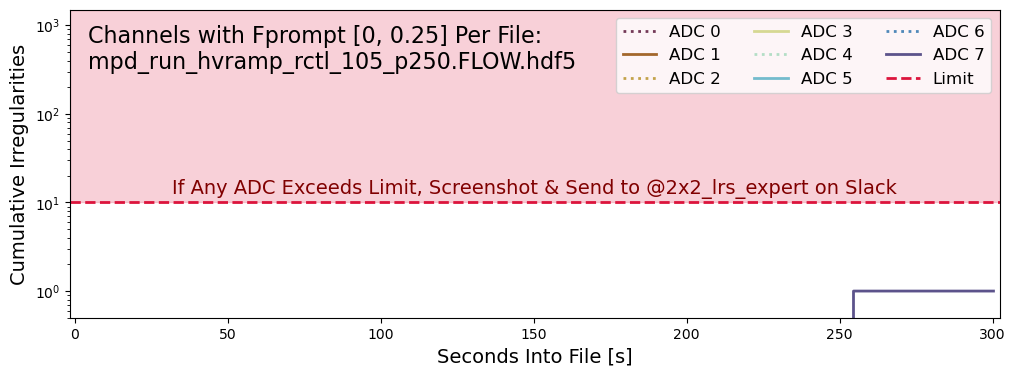

In [10]:
fig, ax = plt.subplots(figsize=(12,4))
x_array = np.arange(0, file_length, np.float32(file_length/(np.shape(array_to_save)[0])))
if len(x_array) > np.shape(array_to_save)[0]:
    x_array = x_array[1:]
elif len(x_array) < np.shape(array_to_save)[0]:
    array_to_save = array_to_save[:len(x_array),:,:]
    
color_array = ['#733957', '#A3672C', '#C3A34B',
               '#D6D893', '#B4DEC6', '#74BBCD',
               '#4F88B9', '#5C538B']

style_array = [':', '-', ':',
               '-', ':', '-',
               ':', '-']

for i in range(N_ADCS):
    ax.plot(x_array, np.cumsum(array_to_save[:,i]), color=color_array[i], linestyle=style_array[i], label=f'ADC {i}', linewidth=2)
print('End Game Sums:', (array_to_save.sum(axis=0)*file_skip_mult)//file_length, ' Hz')
ax.axhline(y=FPROMPT_THD, color='crimson', linestyle='--', label='Limit', linewidth=2)
ax.axhspan(ymin=FPROMPT_THD, ymax=1500, color='crimson', alpha=0.2)
ax.legend(loc='upper right', ncols=3, fontsize=12)
ax.set_ylim(0.5, 1500)
ax.set_yscale('log')
ax.set_xlim(x_array[0]-2,x_array[-1]+2)
ax.set_xlabel('Seconds Into File [s]', fontsize=14)
ax.set_ylabel('Cumulative Irregularities', fontsize=14)
textstr = f'If Any ADC Exceeds Limit, Screenshot & Send to @2x2_lrs_expert on Slack'
#textstr = f'Particle Type: protons\n Vertex in 2x2'
#props = dict(boxstyle='round', facecolor='white', edgecolor='')
ax.text(
    0.5, 0.45, textstr,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top',
    horizontalalignment='center',
    color='maroon'
)
#plt.text(x=5,  y=8, s='If Any ADC Exceeds Limit, Screenshot & Send to @2x2_lrs_expert on Slack', rotation=0, verticalalignment='center', fontsize=12, color='crimson')
plt.title(f'Channels with Fprompt [0, 0.25] Per File:\n{os.path.basename(input_file)}', fontsize=16, loc='left', y=0.78, x=0.02)
plt.show()

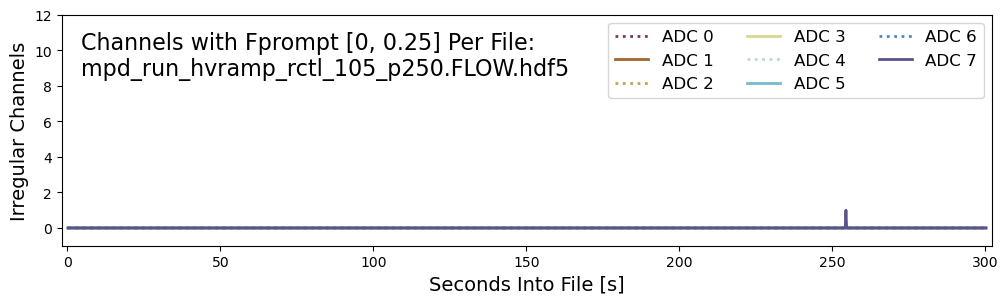

In [11]:
fig, ax = plt.subplots(figsize=(12,3))
x_array = np.arange(0, file_length, np.float32(file_length/(np.shape(array_to_save)[0])))
if len(x_array) > np.shape(array_to_save)[0]:
    x_array = x_array[1:]
elif len(x_array) < np.shape(array_to_save)[0]:
    array_to_save = array_to_save[:len(x_array),:,:]
    
color_array = ['#733957', '#A3672C', '#C3A34B',
               '#D6D893', '#B4DEC6', '#74BBCD',
               '#4F88B9', '#5C538B']

style_array = [':', '-', ':',
               '-', ':', '-',
               ':', '-']

for i in range(N_ADCS):
    ax.plot(x_array, array_to_save[:,i], color=color_array[i], linestyle=style_array[i], label=f'ADC {i}', linewidth=2)
#ax.axhline(y=6, color='crimson', linestyle='--', label='Limit', linewidth=2)
#ax.axhspan(ymin=6, ymax=49, color='crimson', alpha=0.2)
ax.legend(loc='upper right', ncols=3, fontsize=12)
ax.set_ylim(-1, 12)
ax.set_xlim(x_array[0]-2,x_array[-1]+2)
ax.set_xlabel('Seconds Into File [s]', fontsize=14)
ax.set_ylabel('Irregular Channels', fontsize=14)
#textstr = f'If Any ADC Exceeds Limit, Screenshot & Send to @2x2_lrs_expert on Slack'
#textstr = f'Particle Type: protons\n Vertex in 2x2'
#props = dict(boxstyle='round', facecolor='white', edgecolor='')
#ax.text(
#    0.5, 0.22, textstr,
#    transform=ax.transAxes,
#    fontsize=14,
#    verticalalignment='top',
#    horizontalalignment='center',
#    color='maroon'
#)
#plt.text(x=5,  y=8, s='If Any ADC Exceeds Limit, Screenshot & Send to @2x2_lrs_expert on Slack', rotation=0, verticalalignment='center', fontsize=12, color='crimson')
plt.title(f'Channels with Fprompt [0, 0.25] Per File:\n{os.path.basename(input_file)}', fontsize=16, loc='left', y=0.70, x=0.02)
plt.show()

In [12]:
print("Example from Run 2 DTG Data:")
print(f"Beam Trigger Rate: {(np.sum(beam_mask)/file_length):.2f} Hz")
print(f"Self-Trigger Rate: {(np.sum(beam_mask==0)/file_length):.2f} Hz")
print('ADC 0 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[0], ' Hz')
print('ADC 1 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[1], ' Hz')
print('ADC 2 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[2], ' Hz')
print('ADC 3 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[3], ' Hz')
print('ADC 4 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[4], ' Hz')
print('ADC 5 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[5], ' Hz')
print('ADC 6 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[6], ' Hz')
print('ADC 7 Sus Wvfm Rate:', ((array_to_save.sum(axis=0)*file_skip_mult)//file_length)[7], ' Hz')
smallest_time_differences = time_differences[time_differences/1e3 < 5e5]
print(f"Minimum Dead Time: {(np.min(time_differences/1e3)):.2f} μs")

Example from Run 2 DTG Data:
Beam Trigger Rate: 0.76 Hz
Self-Trigger Rate: 12.55 Hz
ADC 0 Sus Wvfm Rate: 0.0  Hz
ADC 1 Sus Wvfm Rate: 0.0  Hz
ADC 2 Sus Wvfm Rate: 0.0  Hz
ADC 3 Sus Wvfm Rate: 0.0  Hz
ADC 4 Sus Wvfm Rate: 0.0  Hz
ADC 5 Sus Wvfm Rate: 0.0  Hz
ADC 6 Sus Wvfm Rate: 0.0  Hz
ADC 7 Sus Wvfm Rate: 0.0  Hz
Minimum Dead Time: 455.17 μs
